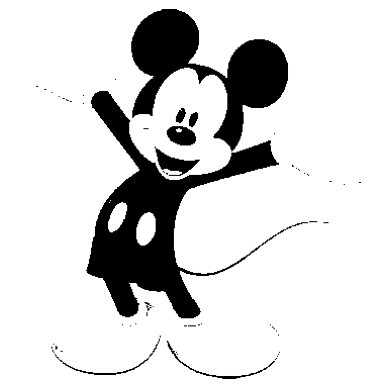

In [1]:
#1. Region-Based Segmentation
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/images.jpg', 0)

_, seg = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

plt.imshow(seg, cmap='gray')
plt.axis('off')
plt.show()

In [3]:
#2. Grid-Based Image Analysis
import cv2

img = cv2.imread('/content/images.jpg', 0)
h, w = img.shape

grid = 4
for i in range(grid):
    for j in range(grid):
        block = img[i*h//grid:(i+1)*h//grid,
                    j*w//grid:(j+1)*w//grid]
        print("Block:", i, j, "Mean:", block.mean())

Block: 0 0 Mean: 241.8903540903541
Block: 0 1 Mean: 132.26800976800976
Block: 0 2 Mean: 144.85494505494506
Block: 0 3 Mean: 250.1175824175824
Block: 1 0 Mean: 251.27234299516908
Block: 1 1 Mean: 134.03961352657004
Block: 1 2 Mean: 166.5743961352657
Block: 1 3 Mean: 243.3909420289855
Block: 2 0 Mean: 242.20439560439561
Block: 2 1 Mean: 118.31672771672771
Block: 2 2 Mean: 248.8103785103785
Block: 2 3 Mean: 253.3760683760684
Block: 3 0 Mean: 230.1949275362319
Block: 3 1 Mean: 168.22946859903382
Block: 3 2 Mean: 200.10567632850243
Block: 3 3 Mean: 254.97729468599033


In [4]:
#3. Shape Matrix (Hu Moments)
import cv2

img = cv2.imread('/content/images.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

M = cv2.moments(binary)
hu = cv2.HuMoments(M)

print("Hu Moments:")
print(hu)

Hu Moments:
[[ 8.64352371e-04]
 [ 1.33298213e-09]
 [ 7.11082770e-13]
 [ 2.24359404e-12]
 [ 1.04647969e-24]
 [ 3.13432942e-17]
 [-2.63354753e-24]]


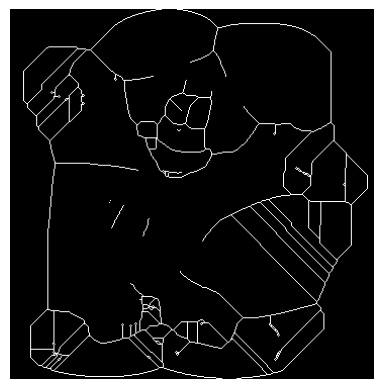

In [5]:
#4. Medial Axis (Skeletonization)
from skimage.morphology import skeletonize
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/images.jpg', 0)
binary = img > 127

skeleton = skeletonize(binary)

plt.imshow(skeleton, cmap='gray')
plt.axis('off')
plt.show()

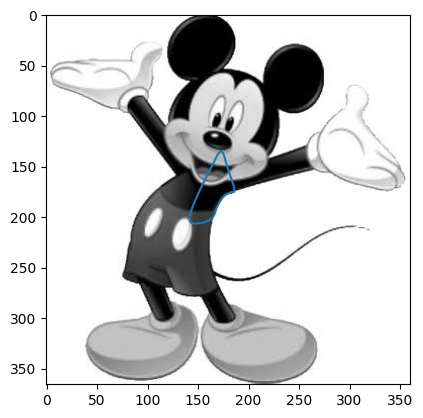

In [6]:
#5. Deformable Curve Model
from skimage.segmentation import active_contour
from skimage.filters import gaussian
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

img = imread('/content/images.jpg', as_gray=True)

s = np.linspace(0, 2*np.pi, 100)
x = img.shape[1]/2 + 50*np.cos(s)
y = img.shape[0]/2 + 50*np.sin(s)

snake = active_contour(gaussian(img, 3), np.array([y, x]).T)

plt.imshow(img, cmap='gray')
plt.plot(snake[:,1], snake[:,0])
plt.show()

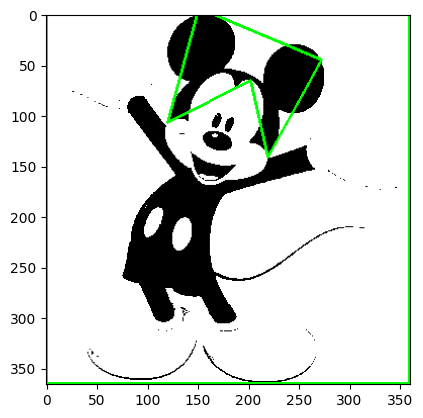

In [7]:
#6. Geometrical Curve Representation
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/images.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

c = contours[0]
epsilon = 0.02 * cv2.arcLength(c, True)
approx = cv2.approxPolyDP(c, epsilon, True)

out = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
cv2.drawContours(out, [approx], -1, (0,255,0), 2)

plt.imshow(out)
plt.show()

In [8]:
#7. Wavelet Descriptor
import cv2
import pywt

img = cv2.imread('/content/images.jpg', 0)

LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')

print("Wavelet Descriptor:")
print("LL:", LL.mean())
print("LH:", LH.mean())
print("HL:", HL.mean())
print("HH:", HH.mean())

Wavelet Descriptor:
LL: 410.0894656952034
LH: 0.04074074074074079
HL: -0.02295081967213116
HH: -0.012416514875531238


In [9]:
#8. Principal Component Analysis (PCA)
import cv2
import numpy as np

img = cv2.imread('/content/images.jpg', 0)

data = img.reshape(-1, 1).astype(np.float32)

mean, eigenvectors = cv2.PCACompute(
    data, mean=None, maxComponents=1)

print("Principal Component:")
print(eigenvectors)

Principal Component:
[[1.]]


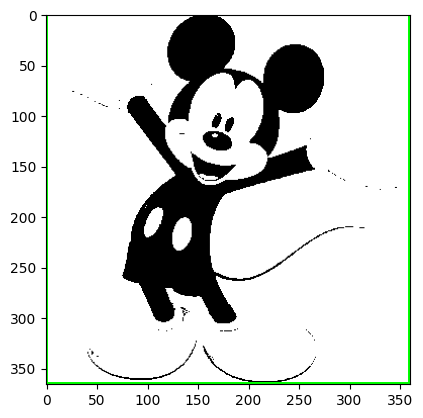

In [10]:
#9. Convex Hull Shape Representation
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/images.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

hull = cv2.convexHull(contours[0])

out = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
cv2.drawContours(out, [hull], -1, (0,255,0), 2)

plt.imshow(out)
plt.show()

In [11]:
#10. Bounding Box Geometric Analysis
import cv2

img = cv2.imread('/content/images.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

x, y, w, h = cv2.boundingRect(contours[0])

print("X:", x)
print("Y:", y)
print("Width:", w)
print("Height:", h)
print("Area:", w*h)

X: 0
Y: 0
Width: 360
Height: 366
Area: 131760
